
## <center> **MAKING SENSE OF UNSTRUCTURED DATA - Customer Personality Segmentation** </center>
### <center> Florencia Nebot </center>



#**Problem Statement**




## **Business Context**

Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.




##**Objective**

In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:

Develop personalized marketing campaigns to increase conversion rates.
Create effective retention strategies for high-value customers.
Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.
As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.

##**Data Dictionary**

The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:


***Customer Information***

**ID:** Unique identifier for each customer.

**Year_Birth:** Customer's year of birth.

**Education:** Education level of the customer.

**Marital_Status:** Marital status of the customer.

**Income:** Yearly household income (in dollars).

**Kidhome:** Number of children in the household.

**Teenhome:** Number of teenagers in the household.

**Dt_Customer:** Date when the customer enrolled with the company.

**Recency:** Number of days since the customer’s last purchase.

**Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).


***Spending Information (Last 2 Years)***

**MntWines:** Amount spent on wine.

**MntFruits:** Amount spent on fruits.

**MntMeatProducts:** Amount spent on meat.

**MntFishProducts:** Amount spent on fish.

**MntSweetProducts:** Amount spent on sweets.

**MntGoldProds:** Amount spent on gold products.

***Purchase and Campaign Interaction***

**NumDealsPurchases:** Number of purchases made using a discount.

**AcceptedCmp1** Response to the 1st campaign (1 for yes, 0 for no).

**AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).

**AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).

**AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).

**AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).

**Response:** Response to the last campaign (1 for yes, 0 for no).


***Shopping Behavior***

**NumWebPurchases:** Number of purchases made through the company’s website.

**NumCatalogPurchases:** Number of purchases made using catalogs.

**NumStorePurchases:** Number of purchases made directly in stores.

**NumWebVisitsMonth:** Number of visits to the company’s website in the last month.


# **Let's start coding!**


##**Importing necessary libraries**


In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

##**Loading Data**

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


In [ ]:
file = pd.read_csv('/content/gdrive/MyDrive/Customer_Personality_Segmentation.csv',sep='\t')
file.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
df = file.copy()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


##**Data Overview**


###**Statistical summary**

**Question 1: What are the data types of all the columns?**


In [ ]:
print('1.Number of Rows and Columns')
print(df.shape)
print()
print('2.Complete summary of the Dataset')
print()
print(df.info())

1.Number of Rows and Columns
(2240, 29)

2.Complete summary of the Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds

**Observations**
*   The dataset contains 2240 rows y 28 columns.
*   It includes 3 categorical variables and 25 numerical variables: 4 int and only one float.
*   The variable Income has missing values that need to be handled.
*   The Z_CostContact variable is not defined in the metadata.
*   The Z_Revenue variable is not defined in the metadata.








**Question 2: Check the statistical summary of the data. What is the average household income?**


In [ ]:
print('3.Summary of numerical variables')
print()
df.describe().T

3.Summary of numerical variables



,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0



**Observations**

*   It is unusual for people born in 1983 or earlier to appear in a dataset of recent purchases. This should be treated as a potential data outlier.
*   The standard deviation of Year_Birth is 11 years, indicating moderate dispersion around the mean. This suggests the dataset covers a specific age range.
*   Most customers have one or no teenage children (Kidhome and Teenhome), indicating mostly small households.
*   Income shows high dispersion and is clearly right-skewed: a few customers have extremely high incomes. Outliers should be analyzed.
*   Customers tend to spend more on wine than other categories. This may be because wine is generally more expensive than fruits or sweet products.The standard deviation of MntWines is relatively high, indicating that some customers spend much more than the average.
*   The maximum spending in the dataset is for meat products.
*   Spending on fish, fruits, and gold products is lower on average, but with high standard deviation, showing that some customers occasionally spend a lot in these categories.
*   Most customers purchase in physical stores and online, although some make many purchases via catalog.
*   Most customers have never accepted a marketing campaign. On average, customers made 2 purchases with discounts, but up to the 75th percentile, most made 3 or fewer. Some customers made many discounted purchases, which increases the average.
*   The level of complaints is very low. Most customers never made a complaint, and the standard deviation is also very low, indicating consistent behavior across the dataset.
*   On average, customers make purchases every 25 days, which is not very frequent considering that they buy meat, fish, and fruits, which are generally perishable. Unless the products are frozen, this frequency might be low for fresh products. The standard deviation is high, suggesting that there are different purchasing behaviors among customers, with some shopping much more frequently than others.















In [ ]:
print('4.Summary of categorical variables')

df.describe(include='object').T

4.Summary of categorical variables


,count,unique,top,freq
Education,2240,5,Graduation,1127
Marital_Status,2240,8,Married,864
Dt_Customer,2240,663,31-08-2012,12


In [ ]:
print(df['Education'].unique())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


In [ ]:
print(df['Marital_Status'].unique())

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']




*   Most customers have an educational level of "Graduation", while the rest of the dataset is distributed among the other four categories.

*   There are nine marital status categories, but the most frequent one in the dataset is "Married". Some categories such as "Absurd" and "YOLO" appear to be incorrect values, and I will need to decide later how to handle this variable.





###**Datatime Treatment**

In [ ]:
print(df['Dt_Customer'].unique()[:20])


['04-09-2012' '08-03-2014' '21-08-2013' '10-02-2014' '19-01-2014'
 '09-09-2013' '13-11-2012' '08-05-2013' '06-06-2013' '13-03-2014'
 '15-11-2013' '10-10-2012' '24-11-2012' '24-12-2012' '31-08-2012'
 '28-03-2013' '03-11-2012' '08-08-2012' '06-01-2013' '23-12-2012']


In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y', errors='raise')
print(df['Dt_Customer'].head())



0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


In [ ]:
print(df['Dt_Customer'].min())
print(df['Dt_Customer'].max())

2012-07-30 00:00:00
2014-06-29 00:00:00




*   I converted the variable Dt_Customer from object to datetime.Customers enrolled in the store between 2012 and 2014. Considering that the dataset is recent, we can say that they are very loyal customers to the company.

###**Missing Values**

**Question 3: Are there any missing values in the data? If yes, treat them using an appropriate method**

In [ ]:
missing_values=df.isnull().sum()
missing_values[missing_values > 0]

,0
Income,24


In [ ]:
print('Total missing values:', int(missing_values[missing_values>0]))
print('Total values of the dataset:', df.shape[0])
print()
print('% missing values:',round((missing_values.sum() / df.shape[0]) * 100, 2))


Total missing values: 24
Total values of the dataset: 2240

% missing values: 1.07


In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)


In [ ]:
missing_values=df.isnull().sum()
missing_values[missing_values > 0]

,0


**Observations**
*   There are 24 records in the dataset with missing values for the Income variable, which represents approximately 1% of the data. However, I consider it appropriate to perform imputation using the median, since the median represents the middle value of the distribution when all data points are ordered from smallest to largest.

###**Duplicates**

**Question 4: Are there any duplicates in the data?**


In [ ]:
df.drop(columns=["ID"])

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [ ]:
print({
    "Count" : df.duplicated().sum()[df.duplicated().sum() > 0],
    "Percentage" : (df.duplicated().sum()[df.duplicated().sum() > 0] / df.shape[0]) * 100})

{'Count': array([], dtype=int64), 'Percentage': array([], dtype=float64)}


In [ ]:
file_withoutID= file.drop(columns=['ID'])
print({
    "Count" : file_withoutID.duplicated().sum()[file_withoutID.duplicated().sum() > 0],
    "Percentage" : (file_withoutID.duplicated().sum()[file_withoutID.duplicated().sum() > 0] / file_withoutID.shape[0]) * 100})

{'Count': array([182]), 'Percentage': array([8.125])}


**Observations**

I check for duplicates before and after the following transformations:

*   Imputation of the Income variable.
*   Adjustment of the Dt_Customer variable format.

The finding is that before both transformations, there are customers with different IDs but identical values across all other variables. In my opinion, the dataset variables are not highly personal identifiers, such as name or ID number. Therefore, I decided to keep the duplicates, as it does not seem unreasonable that two customers of the store could have the same age, income, and spending patterns.

###**Dropping columns which are irrelevant to our analysis.**


In [ ]:
print(df['Z_Revenue'].unique())

[11]


In [ ]:
print(df['Z_CostContact'].unique())

[3]


In [ ]:
df_new = df.drop(columns=["Z_Revenue", "Z_CostContact", "Complain","AcceptedCmp1","AcceptedCmp2",
                       "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", "NumWebVisitsMonth","Dt_Customer","Education","Year_Birth", "Marital_Status",
                          "Recency", "ID"])
df_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2240 non-null   float64
 1   Kidhome              2240 non-null   int64  
 2   Teenhome             2240 non-null   int64  
 3   MntWines             2240 non-null   int64  
 4   MntFruits            2240 non-null   int64  
 5   MntMeatProducts      2240 non-null   int64  
 6   MntFishProducts      2240 non-null   int64  
 7   MntSweetProducts     2240 non-null   int64  
 8   MntGoldProds         2240 non-null   int64  
 9   NumDealsPurchases    2240 non-null   int64  
 10  NumWebPurchases      2240 non-null   int64  
 11  NumCatalogPurchases  2240 non-null   int64  
 12  NumStorePurchases    2240 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 227.6 KB


In [ ]:
duplicados2 = df_new[df.duplicated()]
duplicados2

,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases


**Reasons why I am removing variables**

They don't seem relevant for customer segmentation, beacuse there are constants variables (Z_CostContact), or they have lot of errors (marital status). The standard deviation of the Year_Birth variable seems too low to effectively segment by age range; therefore, I will also remove it from my analysis.




#**Exploratory Data Analysis**


##**Univariate Analysis**


**Question 5: Explore all the variables and provide observations on their distributions. (histograms and boxplots)**

###**1.Outliers**

In [ ]:
numericas = df_new.select_dtypes(include=['number'])
numericas

,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,58138.0,0,0,635,88,546,172,88,88,3,8,10,4
1,46344.0,1,1,11,1,6,2,1,6,2,1,1,2
2,71613.0,0,0,426,49,127,111,21,42,1,8,2,10
3,26646.0,1,0,11,4,20,10,3,5,2,2,0,4
4,58293.0,1,0,173,43,118,46,27,15,5,5,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,709,43,182,42,118,247,2,9,3,4
2236,64014.0,2,1,406,0,30,0,0,8,7,8,2,5
2237,56981.0,0,0,908,48,217,32,12,24,1,2,3,13
2238,69245.0,0,1,428,30,214,80,30,61,2,6,5,10


In [ ]:
variables_with_outliers = []

for col in numericas.columns:
    Q1 = df_new[col].quantile(0.25) #First quartile of each variable
    Q3 = df_new[col].quantile(0.75) #Third quartile of each variable
    IQR = Q3 - Q1               #Interquartile range (it defines the upper and lower limits) is the difference between the third quartile and the first.
    lower_limit = Q1 - 1.5 * IQR #calculation of the lower limit
    upper_limit = Q3 + 1.5 * IQR #calculation of the upper limit

    outliers = df_new[(df_new[col] < lower_limit) | (df_new[col] > upper_limit)]

    if not outliers.empty:
        variables_with_outliers.append(col)

# Print only the names of the variables with outliers.
print("Variables with outliers:")
for var in variables_with_outliers:
    print(var)

Variables with outliers:
Income
MntWines
MntFruits
MntMeatProducts
MntFishProducts
MntSweetProducts
MntGoldProds
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases


###**2.Boxplot of NumCatalogPurchases**

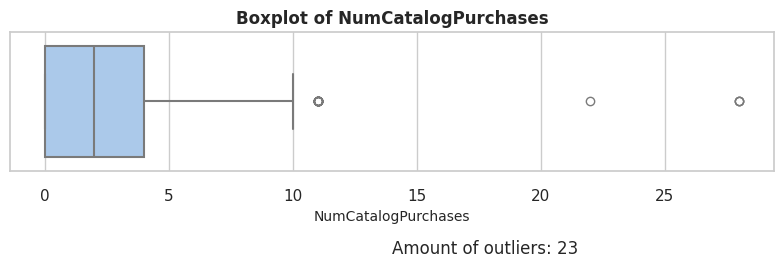

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['NumCatalogPurchases'].quantile(0.25)
Q3 = df_new['NumCatalogPurchases'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['NumCatalogPurchases'] < lower_limit) | (df_new['NumCatalogPurchases'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['NumCatalogPurchases'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of NumCatalogPurchases', fontsize=12, weight='bold')
plt.xlabel('NumCatalogPurchases', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()


*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   Looking at this graph, it is clear that most customers purchase from the catalog up to four times. However, there is a minority who make many catalog purchases.




###**3.Boxplot of NumWebPurchases**

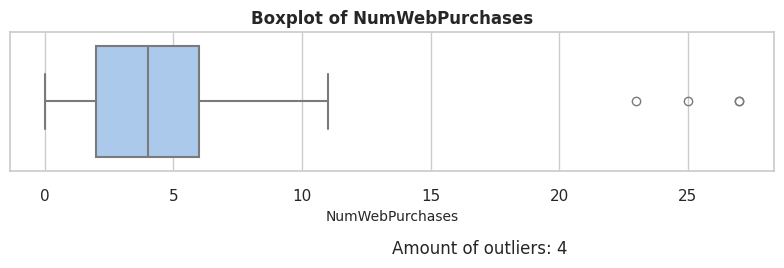

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['NumWebPurchases'].quantile(0.25)
Q3 = df_new['NumWebPurchases'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['NumWebPurchases'] < lower_limit) | (df_new['NumWebPurchases'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['NumWebPurchases'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of NumWebPurchases', fontsize=12, weight='bold')
plt.xlabel('NumWebPurchases', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()

*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   Looking at this graph, it is clear that most customers
purchase from the web up to 5 times. However, there is a minority who make many web purchases.

###**4.Boxplot of NumDealsPurchases**

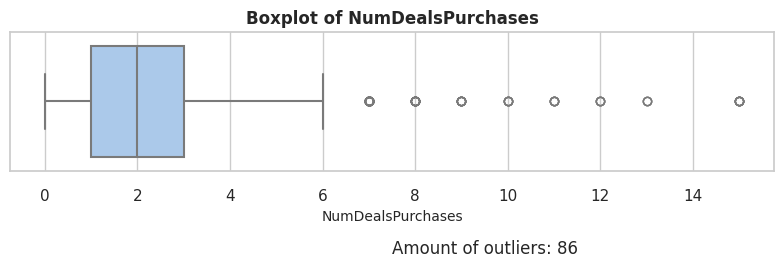

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['NumDealsPurchases'].quantile(0.25)
Q3 = df_new['NumDealsPurchases'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['NumDealsPurchases'] < lower_limit) | (df_new['NumDealsPurchases'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['NumDealsPurchases'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of NumDealsPurchases', fontsize=12, weight='bold')
plt.xlabel('NumDealsPurchases', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()

   *   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.


###**5.Boxplot of MntGoldProds**

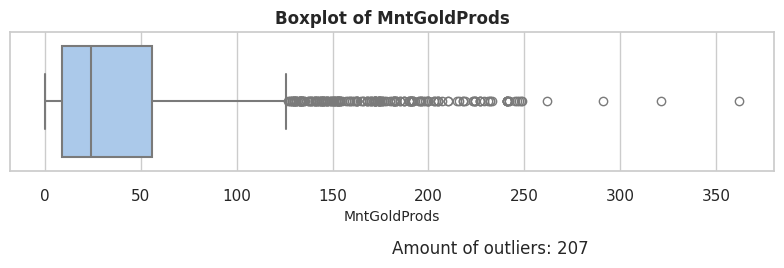

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['MntGoldProds'].quantile(0.25)
Q3 = df_new['MntGoldProds'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['MntGoldProds'] < lower_limit) | (df_new['MntGoldProds'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['MntGoldProds'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of MntGoldProds', fontsize=12, weight='bold')
plt.xlabel('MntGoldProds', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()



*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   The presence of many outliers on the upper end suggests a **right-skewed** distribution, meaning that some customers spend significantly more than the majority.



###**6.Boxplot of MntSweetProducts**

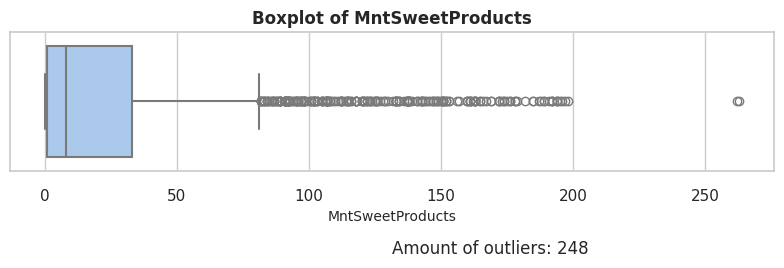

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['MntSweetProducts'].quantile(0.25)
Q3 = df_new['MntSweetProducts'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['MntSweetProducts'] < lower_limit) | (df_new['MntSweetProducts'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['MntSweetProducts'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of MntSweetProducts', fontsize=12, weight='bold')
plt.xlabel('MntSweetProducts', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()

*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   The presence of many outliers on the upper end suggests a **right-skewed** distribution, meaning that some customers spend significantly more than the majority.

###**7.Boxplot of MntFishProducts**

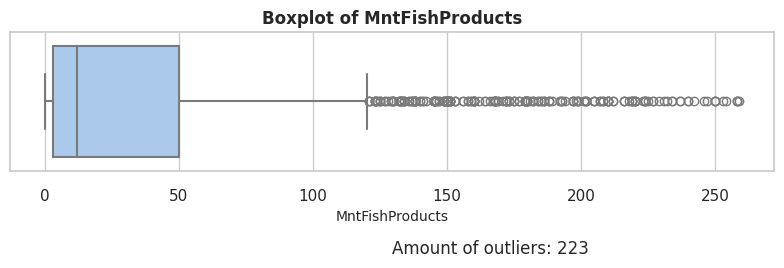

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['MntFishProducts'].quantile(0.25)
Q3 = df_new['MntFishProducts'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['MntFishProducts'] < lower_limit) | (df_new['MntFishProducts'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['MntFishProducts'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of MntFishProducts', fontsize=12, weight='bold')
plt.xlabel('MntFishProducts', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()

*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   The presence of many outliers on the upper end suggests a **right-skewed** distribution, meaning that some customers spend significantly more than the majority.

###**8.Boxplot of MntMeatProducts**

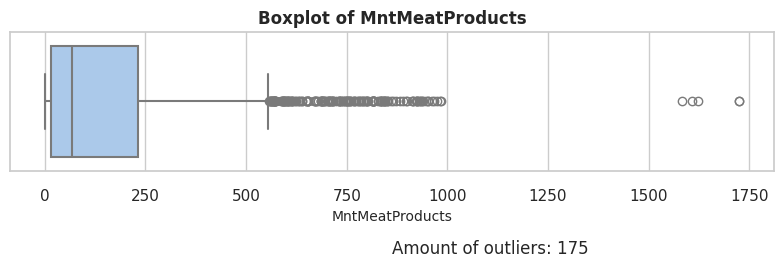

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['MntMeatProducts'].quantile(0.25)
Q3 = df_new['MntMeatProducts'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['MntMeatProducts'] < lower_limit) | (df['MntMeatProducts'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df_new['MntMeatProducts'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of MntMeatProducts', fontsize=12, weight='bold')
plt.xlabel('MntMeatProducts', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()

*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   The presence of many outliers on the upper end suggests a **right-skewed** distribution, meaning that some customers spend significantly more than the majority.

###**9.Boxplot of MntFruits**

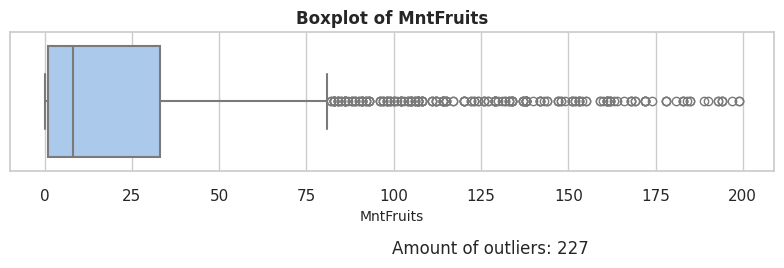

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['MntFruits'].quantile(0.25)
Q3 = df_new['MntFruits'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['MntFruits'] < lower_limit) | (df_new['MntFruits'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df_new['MntFruits'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of MntFruits', fontsize=12, weight='bold')
plt.xlabel('MntFruits', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()

*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   The presence of many outliers on the upper end suggests a **right-skewed** distribution, meaning that some customers spend significantly more than the majority.

###**10.Boxplot of MntWines**

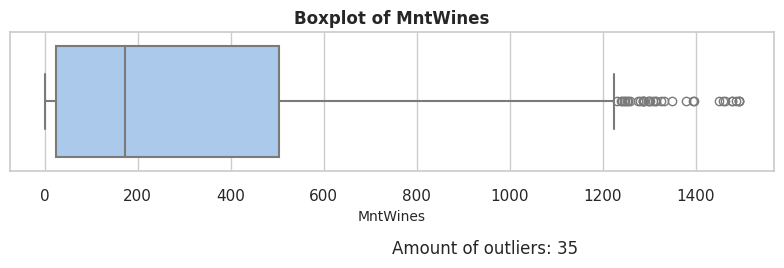

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['MntWines'].quantile(0.25)
Q3 = df_new['MntWines'].quantile(0.75)
IQR = Q3 - Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['MntWines'] < lower_limit) | (df_new['MntWines'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['MntWines'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of MntWines', fontsize=12, weight='bold')
plt.xlabel('MntWines', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()



*   Most customers spend between 50 and 400 on wine, but there is a small group that spends significantly more, which could represent a premium or high-value segment.
*   The median spending is 200, which gives us an idea of typical behavior, although the outliers invite us to explore segmentation opportunities.


*   Although this variable presents outliers, the decision is to keep them since they reflect individual consumption choices.
*   The presence of many outliers on the upper end suggests a **right-skewed** distribution, meaning that some customers spend significantly more than the majority.






###**11.Boxplot of Income**

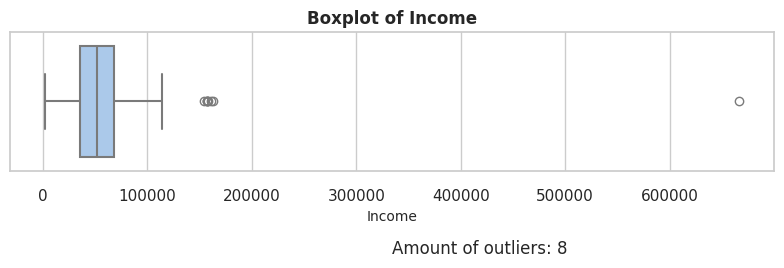

In [ ]:
sns.set(style="whitegrid", palette="pastel")

Q1 = df_new['Income'].quantile(0.25)
Q3 = df_new['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_new[(df_new['Income'] < lower_limit) | (df_new['Income'] > upper_limit)]
n_outliers = len(outliers)

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['Income'], color=sns.color_palette("pastel")[0], linewidth=1.5)

plt.title('Boxplot of Income', fontsize=12, weight='bold')
plt.xlabel('Income', fontsize=10)

plt.yticks([])

plt.figtext(0.5, -0.05, f'Amount of outliers: {n_outliers}'),
plt.tight_layout()
plt.show()


In [ ]:
df_new = df_new[(df_new['Income'] >= lower_limit) & (df_new['Income'] <= upper_limit)]
df_new.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2232 entries, 0 to 2239
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2232 non-null   float64
 1   Kidhome              2232 non-null   int64  
 2   Teenhome             2232 non-null   int64  
 3   MntWines             2232 non-null   int64  
 4   MntFruits            2232 non-null   int64  
 5   MntMeatProducts      2232 non-null   int64  
 6   MntFishProducts      2232 non-null   int64  
 7   MntSweetProducts     2232 non-null   int64  
 8   MntGoldProds         2232 non-null   int64  
 9   NumDealsPurchases    2232 non-null   int64  
 10  NumWebPurchases      2232 non-null   int64  
 11  NumCatalogPurchases  2232 non-null   int64  
 12  NumStorePurchases    2232 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 244.1 KB


##**Bivariate Analysis**


**Question 6: Perform multivariate analysis to explore the relationsips between the variables.**


###**1.Barplot: Kidhome - Total Spending**

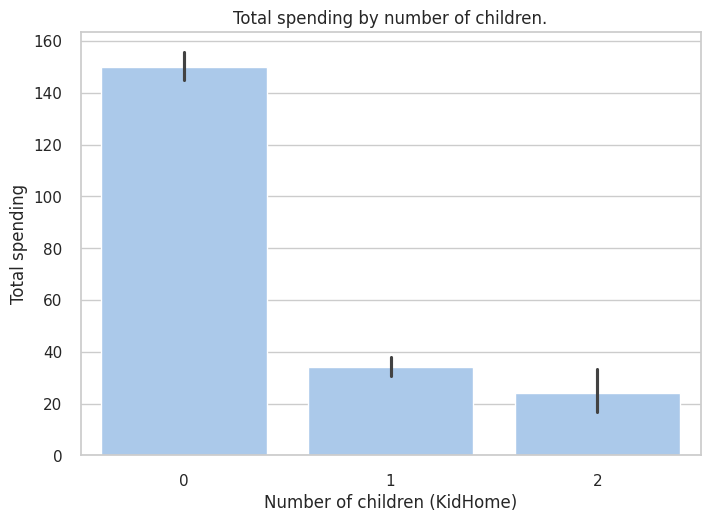

In [ ]:
sns.barplot(data=df_new, x='Kidhome', y=df_new[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].mean(axis=1))
plt.title('Total spending by number of children.')
plt.xlabel('Number of children (KidHome)')
plt.ylabel('Total spending')
plt.show()


###**2.Barplot: Teenhome - Total Spending**

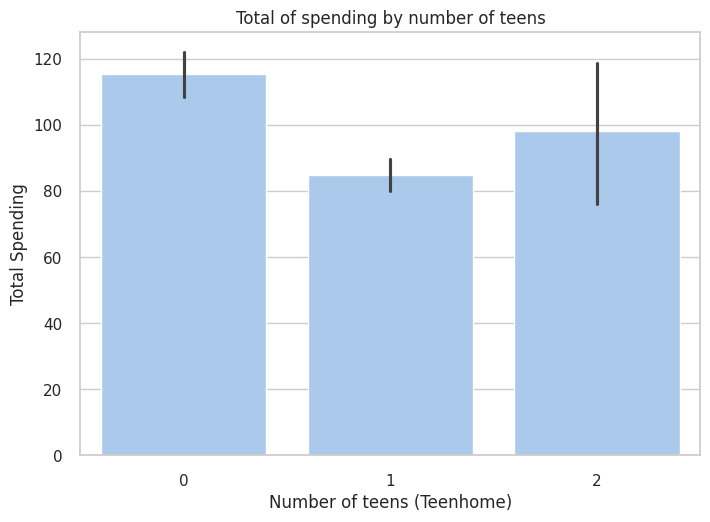

In [ ]:
sns.barplot(data=df, x='Teenhome', y=df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].mean(axis=1))
plt.title('Total of spending by number of teens')
plt.xlabel('Number of teens (Teenhome)')
plt.ylabel('Total Spending')
plt.show()


###**3.Stripplot: Kidhome - MntWines**

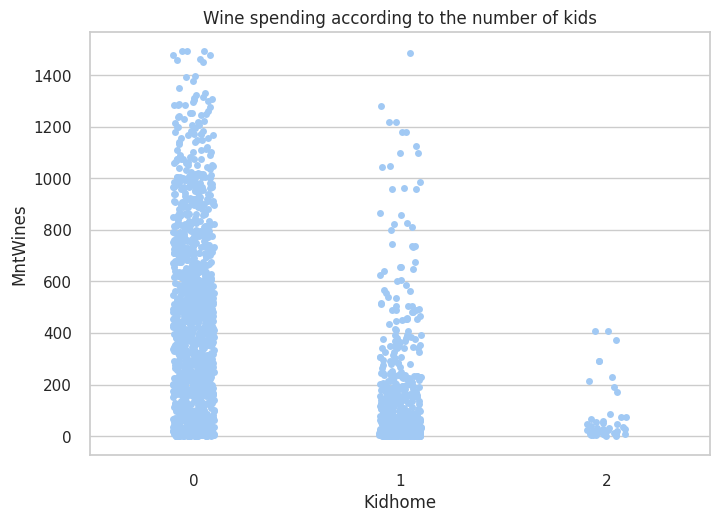

In [ ]:
sns.stripplot(data=df_new, x='Kidhome', y='MntWines', jitter=True)
plt.title('Wine spending according to the number of kids')
plt.show()

###**4.Stripplot: Teenhome - MntWines**

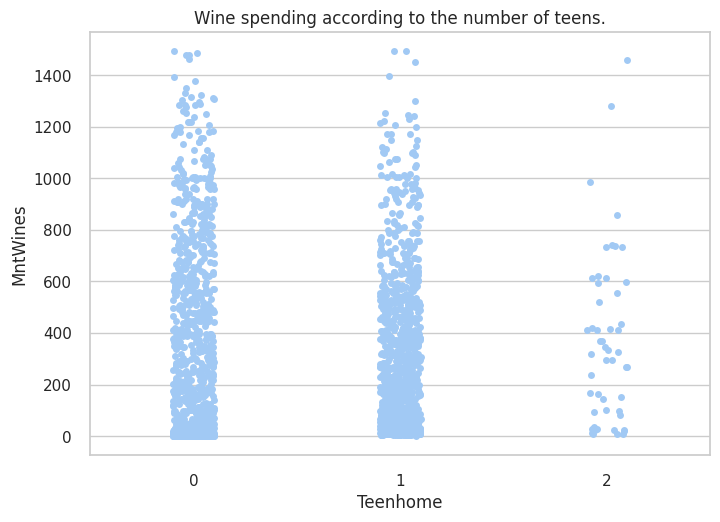

In [ ]:
sns.stripplot(data=df_new, x='Teenhome', y='MntWines', jitter=True)
plt.title('Wine spending according to the number of teens.')
plt.show()

###**5.Stripplot: Kidhome - Amount spent on fruits**

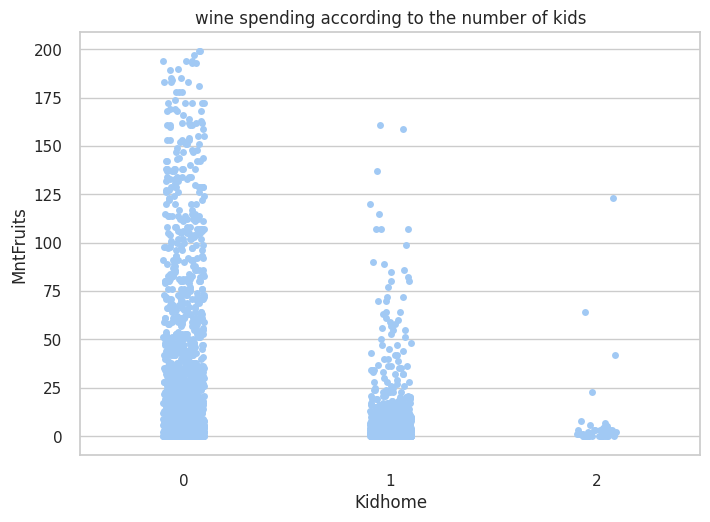

In [ ]:
sns.stripplot(data=df, x='Kidhome', y='MntFruits', jitter=True)
plt.title('wine spending according to the number of kids')
plt.show()

###6.Stripplot: Teenhome - Amount spent on fruits

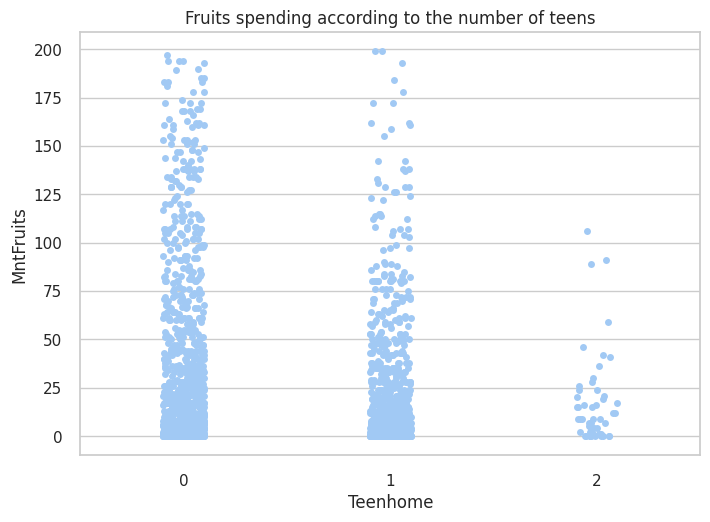

In [ ]:
sns.stripplot(data=df, x='Teenhome', y='MntFruits', jitter=True)
plt.title('Fruits spending according to the number of teens')
plt.show()

###**7.Stripplot: Kidhome - Amount spent on meat**

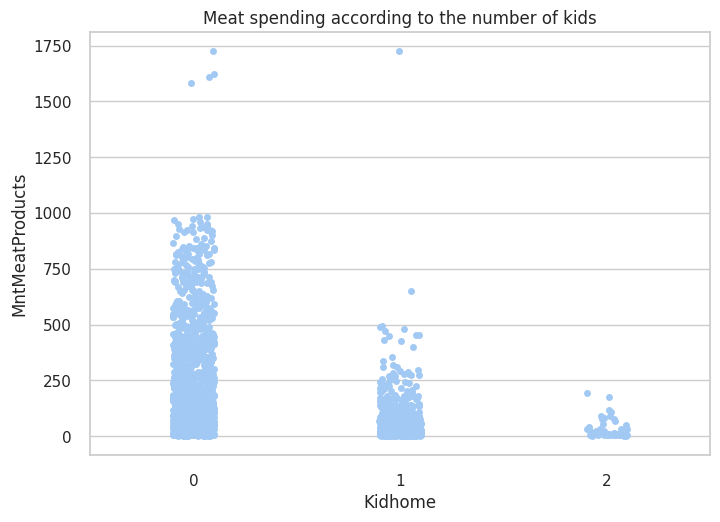

In [ ]:
sns.stripplot(data=df, x='Kidhome', y='MntMeatProducts', jitter=True)
plt.title('Meat spending according to the number of kids')
plt.show()

###**8.Stripplot: Teenhome - Amount spent on meat**

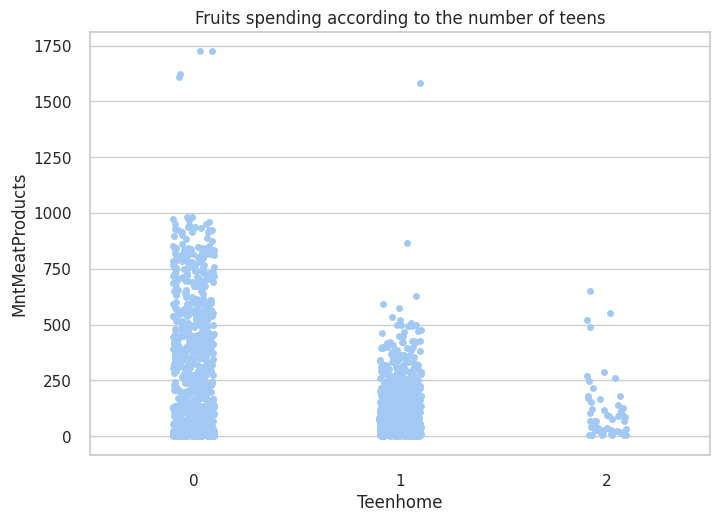

In [ ]:
sns.stripplot(data=df, x='Teenhome', y='MntMeatProducts', jitter=True)
plt.title('Fruits spending according to the number of teens')
plt.show()

###**9.Stripplot: Kidhome - Amount spent on fish**

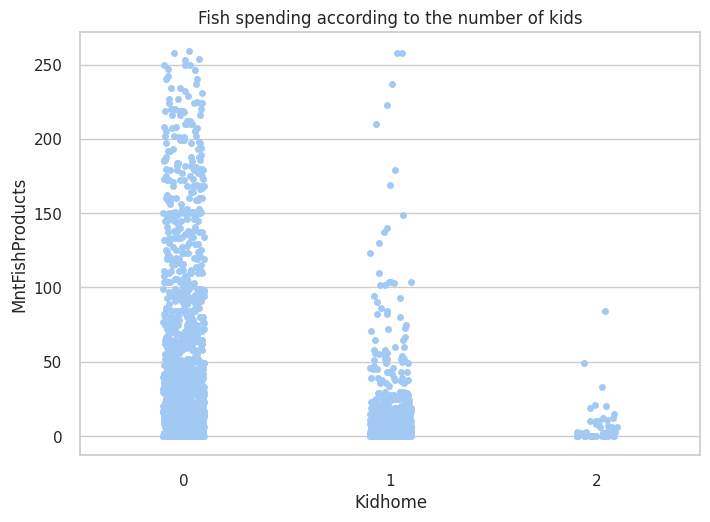

In [ ]:
sns.stripplot(data=df, x='Kidhome', y='MntFishProducts', jitter=True)
plt.title('Fish spending according to the number of kids')
plt.show()

###**10.Stripplot: Teenhome - Amount spent on fish**

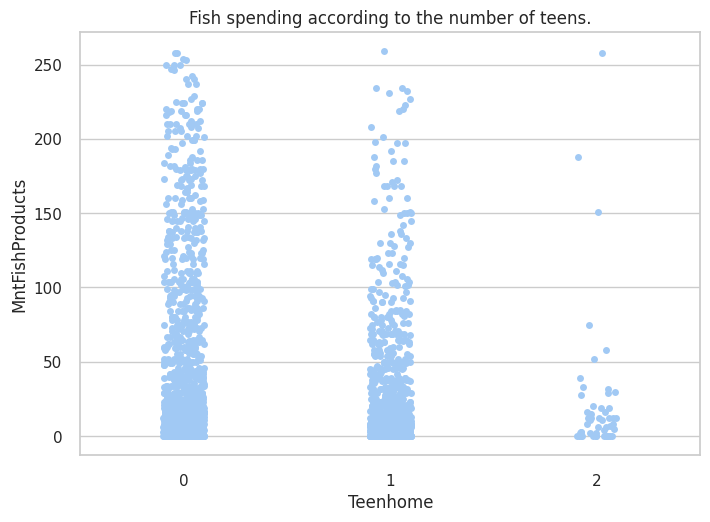

In [ ]:
sns.stripplot(data=df, x='Teenhome', y='MntFishProducts', jitter=True)
plt.title('Fish spending according to the number of teens.')
plt.show()

###**11.Stripplot: Kidhome - Amount spent on sweet products**

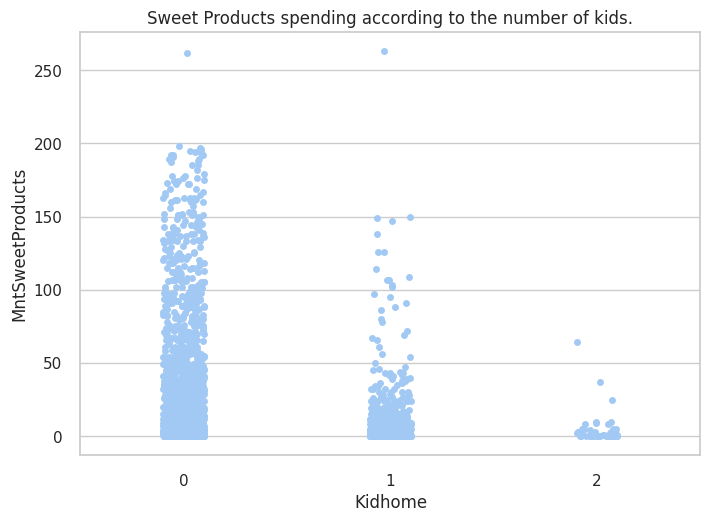

In [ ]:
sns.stripplot(data=df, x='Kidhome', y='MntSweetProducts', jitter=True)
plt.title('Sweet Products spending according to the number of kids.')
plt.show()

###**12.Stripplot: Teenhome - Amount spent on sweet products**

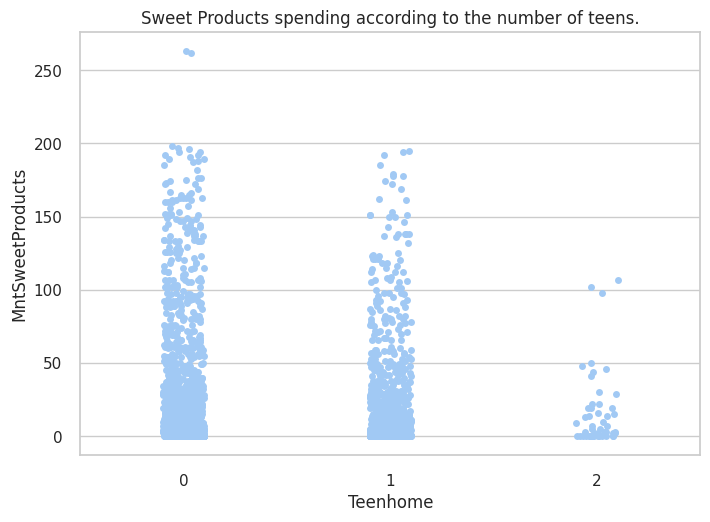

In [ ]:
sns.stripplot(data=df, x='Teenhome', y='MntSweetProducts', jitter=True)
plt.title('Sweet Products spending according to the number of teens.')
plt.show()

###**13.Scatterplot: Recency - Amount spent on fruits**

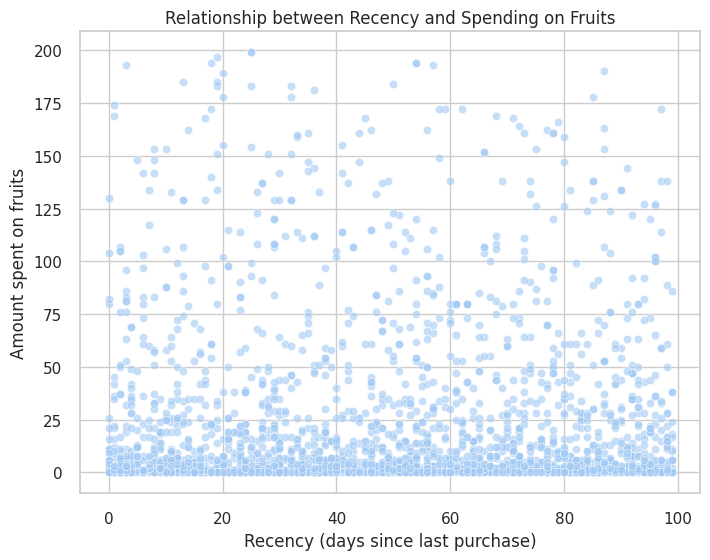

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Recency', y='MntFruits', alpha=0.6)
plt.title('Relationship between Recency and Spending on Fruits')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Amount spent on fruits')
plt.show()

**Observations**

*   There appears to be a high concentration of low-spending data points in the area of low recency, which could suggest that customers who spend less tend to purchase more frequently. Conversely, higher spending values seem more dispersed and associated with higher recency, possibly indicating less frequent but larger purchases.


###**14.Scatterplot: Recency - Amount spent on meat**

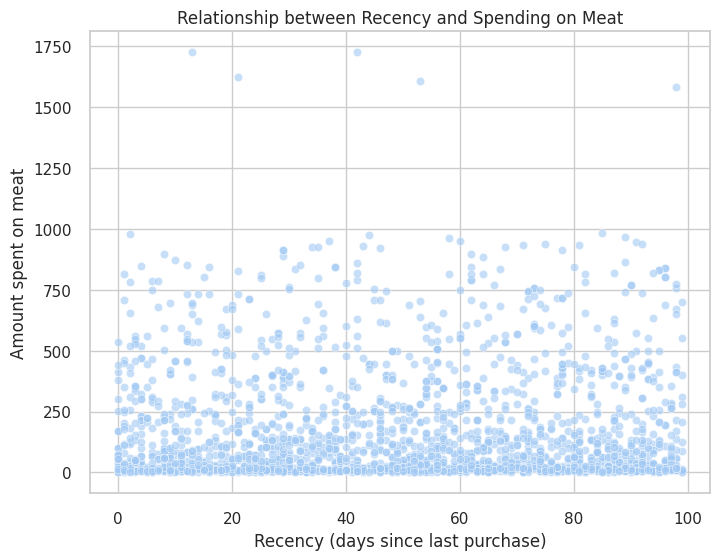

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Recency', y='MntMeatProducts', alpha=0.6)
plt.title('Relationship between Recency and Spending on Meat')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Amount spent on meat')
plt.show()

**Observations**


*   There doesn’t appear to be a clear relationship between recency and spending on meat. Customers may spend either a lot or a little regardless of how recently they made their last purchase.

###**15.Countplot: Total Children**

In [ ]:
df_new5=df_new.copy()

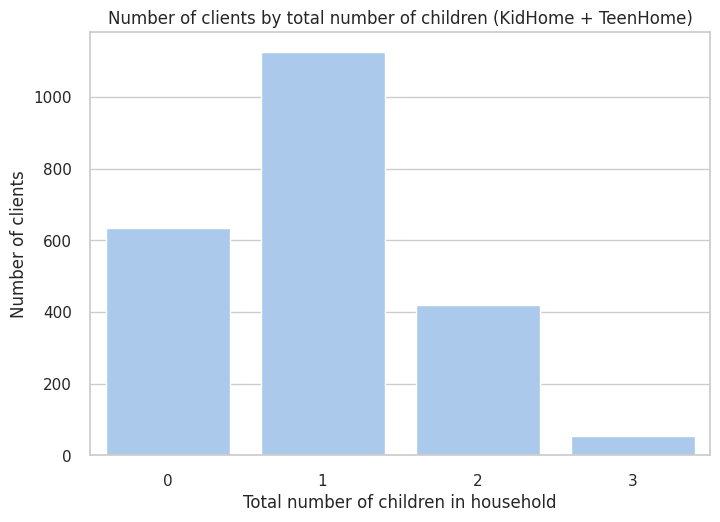

In [ ]:
df_new5['TotalChildren'] = df_new5['Kidhome'] + df_new5['Teenhome']
sns.countplot(data=df_new5, x='TotalChildren')
plt.title('Number of clients by total number of children (KidHome + TeenHome)')
plt.xlabel('Total number of children in household')
plt.ylabel('Number of clients')
plt.show()

**Observations**

*   Most clients have children, compared to those without any.





###**16.Correlation Heatmap**

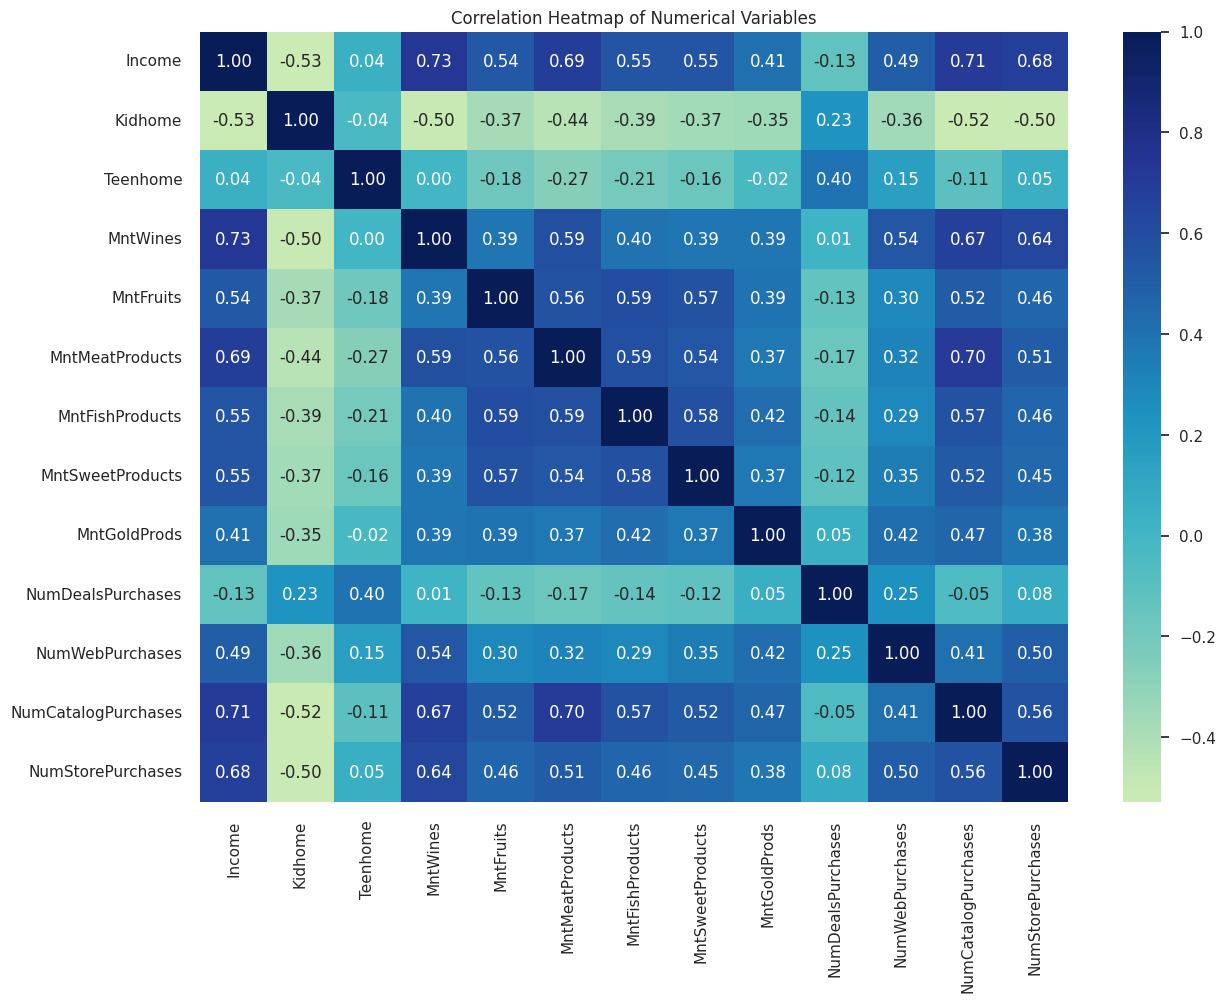

In [ ]:
numeric_df = df_new.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGnBu', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Observations**


*   There is a strong positive correlation between MntMeatProducts and NumCatalogPurchases. This suggests that customers who buy meat tend to do so through the catalog channel.
*   There is a positive correlation between spending on different products (fruits, sweets, meat, etc.), which indicates that customers tend to buy more than one type of product at the store.
*   The correlation between the amount spent on each product and the amount of purchases made with discounts is very weak. This seems to suggest that discounts are not particularly attractive to customers
*   The correlation between income level and spending on different products is positive but weak. The only product types that stand out with a somewhat stronger correlation are wine and gold. This makes sense, as these are generally more expensive items.
*   There are no significant correlations between the number of children or teenagers in customers' households. Based on this, we can infer that the store may not be the preferred choice for customers with children. Perhaps this is because it doesn’t offer wholesale options or products specialized for children or teenagers.









# **K-means Clustering**


**Question 7 : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?**

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2232 entries, 0 to 2239
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2232 non-null   float64
 1   Kidhome              2232 non-null   int64  
 2   Teenhome             2232 non-null   int64  
 3   MntWines             2232 non-null   int64  
 4   MntFruits            2232 non-null   int64  
 5   MntMeatProducts      2232 non-null   int64  
 6   MntFishProducts      2232 non-null   int64  
 7   MntSweetProducts     2232 non-null   int64  
 8   MntGoldProds         2232 non-null   int64  
 9   NumDealsPurchases    2232 non-null   int64  
 10  NumWebPurchases      2232 non-null   int64  
 11  NumCatalogPurchases  2232 non-null   int64  
 12  NumStorePurchases    2232 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 244.1 KB


In [ ]:
# scaling the data before clustering
scaler = StandardScaler()
subset = df_new.copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
# creating a dataframe of the scaled data
subset_scaled_data = pd.DataFrame(subset_scaled, columns=subset.columns)

In [ ]:
k_means_data = subset_scaled_data.copy()


##**Selecting k with the Elbow Method**

Number of Clusters: 2 	WCSS: 18429.740488450017
Number of Clusters: 3 	WCSS: 15379.066910274065
Number of Clusters: 4 	WCSS: 14314.077163971122
Number of Clusters: 5 	WCSS: 13355.458105481526
Number of Clusters: 6 	WCSS: 12464.195021208541
Number of Clusters: 7 	WCSS: 11891.258666279538
Number of Clusters: 8 	WCSS: 11386.698411558426
Number of Clusters: 9 	WCSS: 10993.393434319967
Number of Clusters: 10 	WCSS: 10643.511938691994


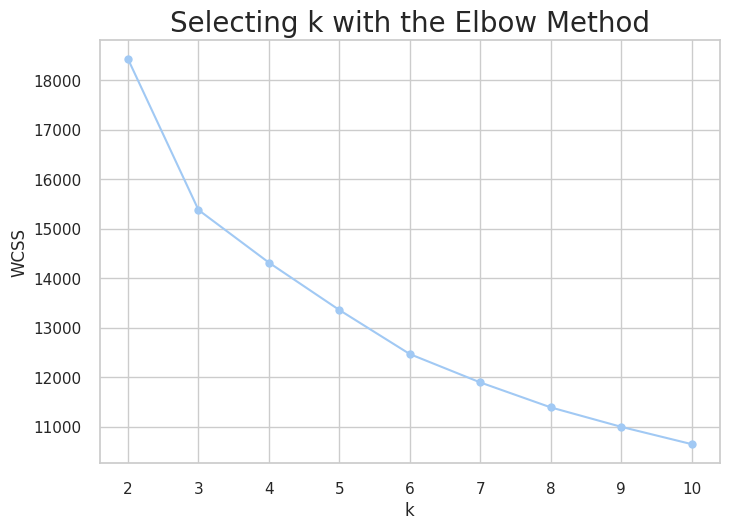

In [ ]:
clusters = range(2, 11)
wcss_k8 = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1, n_init=10) # initialize the kmeans model with k
    model.fit(subset_scaled_data) # fit the kmeans model on the scaled data.
    wcss = model.inertia_
    wcss_k8.append(wcss)

    print("Number of Clusters:", k, "\tWCSS:",wcss)

plt.plot(clusters, wcss_k8, "bx-", marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

##**Silhouette Score vs Number of Clusters**

**Question 8 : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?**


For n_clusters = 2, the silhouette score is 0.35943253682327714)
For n_clusters = 3, the silhouette score is 0.2965288242750529)
For n_clusters = 4, the silhouette score is 0.21639982174792438)
For n_clusters = 5, the silhouette score is 0.2064197169392359)
For n_clusters = 6, the silhouette score is 0.21378348242798947)
For n_clusters = 7, the silhouette score is 0.2119030403994737)
For n_clusters = 8, the silhouette score is 0.22375067492547937)
For n_clusters = 9, the silhouette score is 0.22182716612136982)


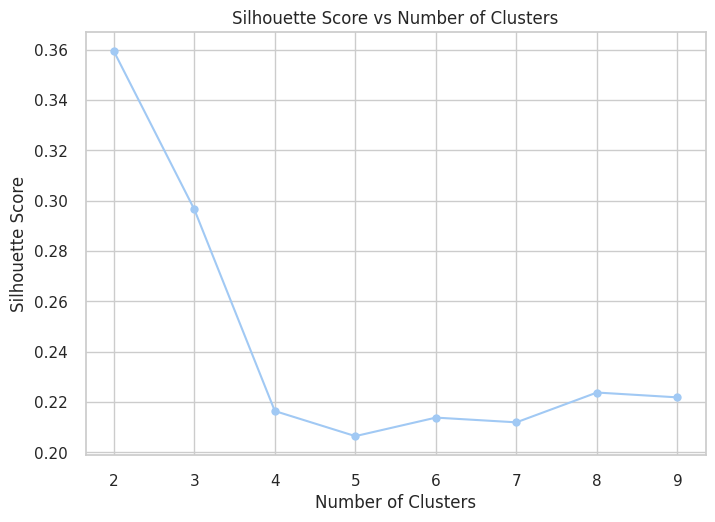

In [ ]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)       # initialize the kmeans model with the number o clusters.
    preds = clusterer.fit_predict(k_means_data)                  # Fit the kmeans model
    score = silhouette_score(k_means_data, preds)             # Check the silhoutte score against the predictions
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

##**Determine the optimal number of clusters**

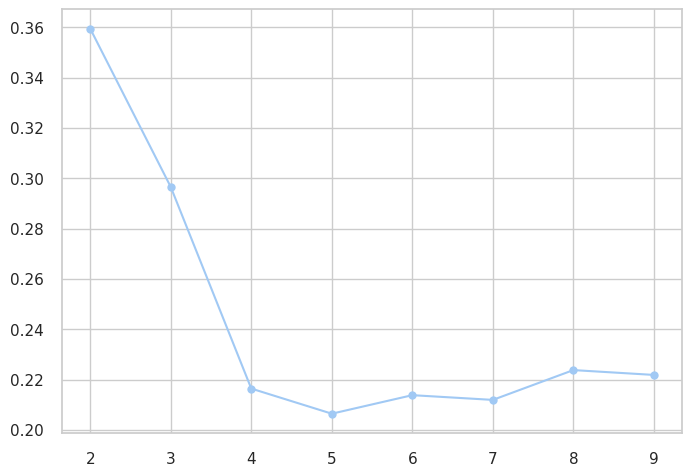

In [ ]:
plt.plot(cluster_list, sil_score, marker = 'o')
plt.show()

**Question 9: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?**


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(k_means_data)

KMeans(n_clusters=2, random_state=42)

**Conclusion**

I decided to use two clusters according to the suggestion of the Silhouette Score. This decision also took into account the exploratory analysis of the variables. The model’s training time was 0 seconds.

In [ ]:
# creating a copy of the original data
df_new2 = df_new.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_data["K_means_segments"] = kmeans.labels_
df_new2["K_means_segments"] = kmeans.labels_

In [ ]:
k_means_data["K_means_segments"].value_counts()

,count
K_means_segments,
0,1307
1,925


In [ ]:
# Update the list of features to match the columns in df_new2
features = ['Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases']

# The column containing cluster labels in df_new2 is 'K_means_segments'
cluster_col = 'K_means_segments'

mean = df_new2.groupby(cluster_col)[features].mean()
median = df_new2.groupby(cluster_col)[features].median()

df_kmeans = pd.concat([mean, median], axis=0)

clusters = mean.index.tolist()
new_index = [f"group_{c} Mean" for c in clusters] + [f"group_{c} Median" for c in clusters]
df_kmeans.index = new_index

df_kmeans[features].T

,group_0 Mean,group_1 Mean,group_0 Median,group_1 Median
Income,38301.975899,70464.374595,38196.0,70777.0
Kidhome,0.706963,0.073514,1.0,0.0
Teenhome,0.553940,0.441081,1.0,0.0
MntWines,94.303749,602.539459,32.0,561.0
MntFruits,6.224178,54.860541,3.0,40.0
MntMeatProducts,35.281561,349.059459,19.0,286.0
MntFishProducts,9.162204,77.889730,4.0,62.0
MntSweetProducts,6.201989,56.762162,3.0,41.0
MntGoldProds,21.491966,76.204324,12.0,55.0
NumDealsPurchases,2.532517,2.015135,2.0,1.0


# **Cluster Profiling and Comparison**


**Question 10: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.**

##**Boxplot of numerical variables for each cluster in Kmeans Clustering**

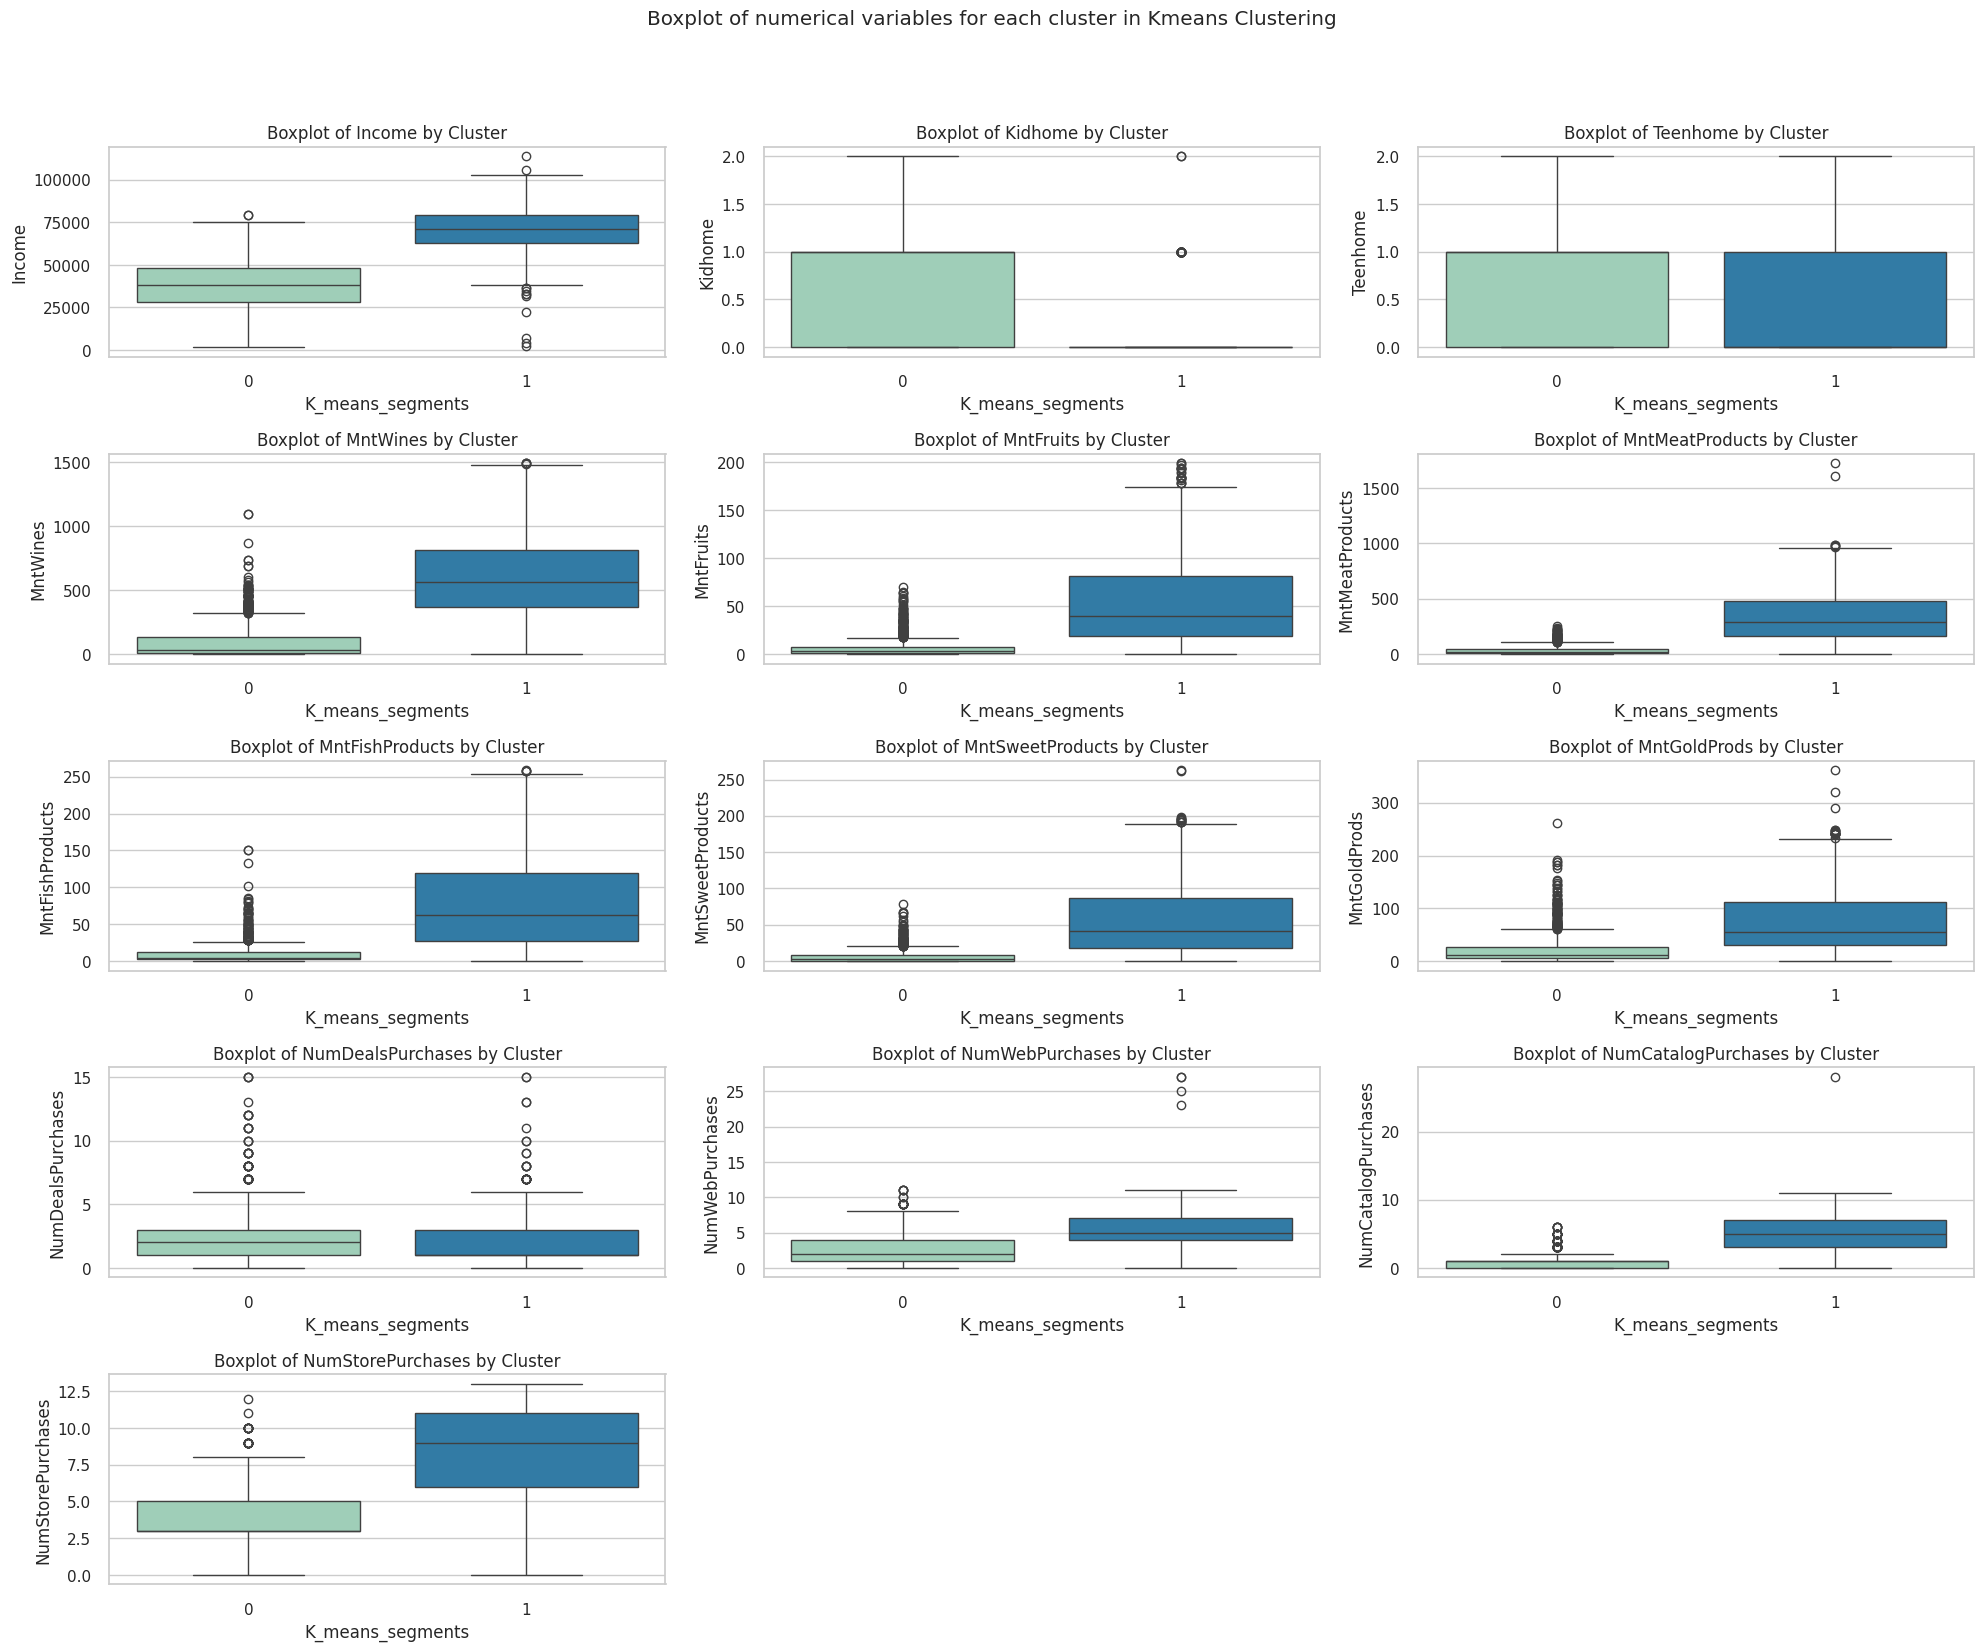

In [ ]:
plt.figure(figsize=(20, 20))  # Set the figure size for the plot
plt.suptitle("Boxplot of numerical variables for each cluster in Kmeans Clustering")  # Set the main title for the plot

# Iterate over each numerical variable in the dataframe
for i, variable in enumerate(df_new2.columns.to_list()[:-1]):
    plt.subplot(6, 3, i + 1)  # Create subplots in a 3x4 grid, starting from index 1
    sns.boxplot(data=df_new2, x='K_means_segments', y=variable, palette='YlGnBu')
    plt.title(f'Boxplot of {variable} by Cluster') # Add a title to each subplot

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent titles overlapping
plt.show()

##**Barplots of all variables for each cluster**

**Question 11: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.**


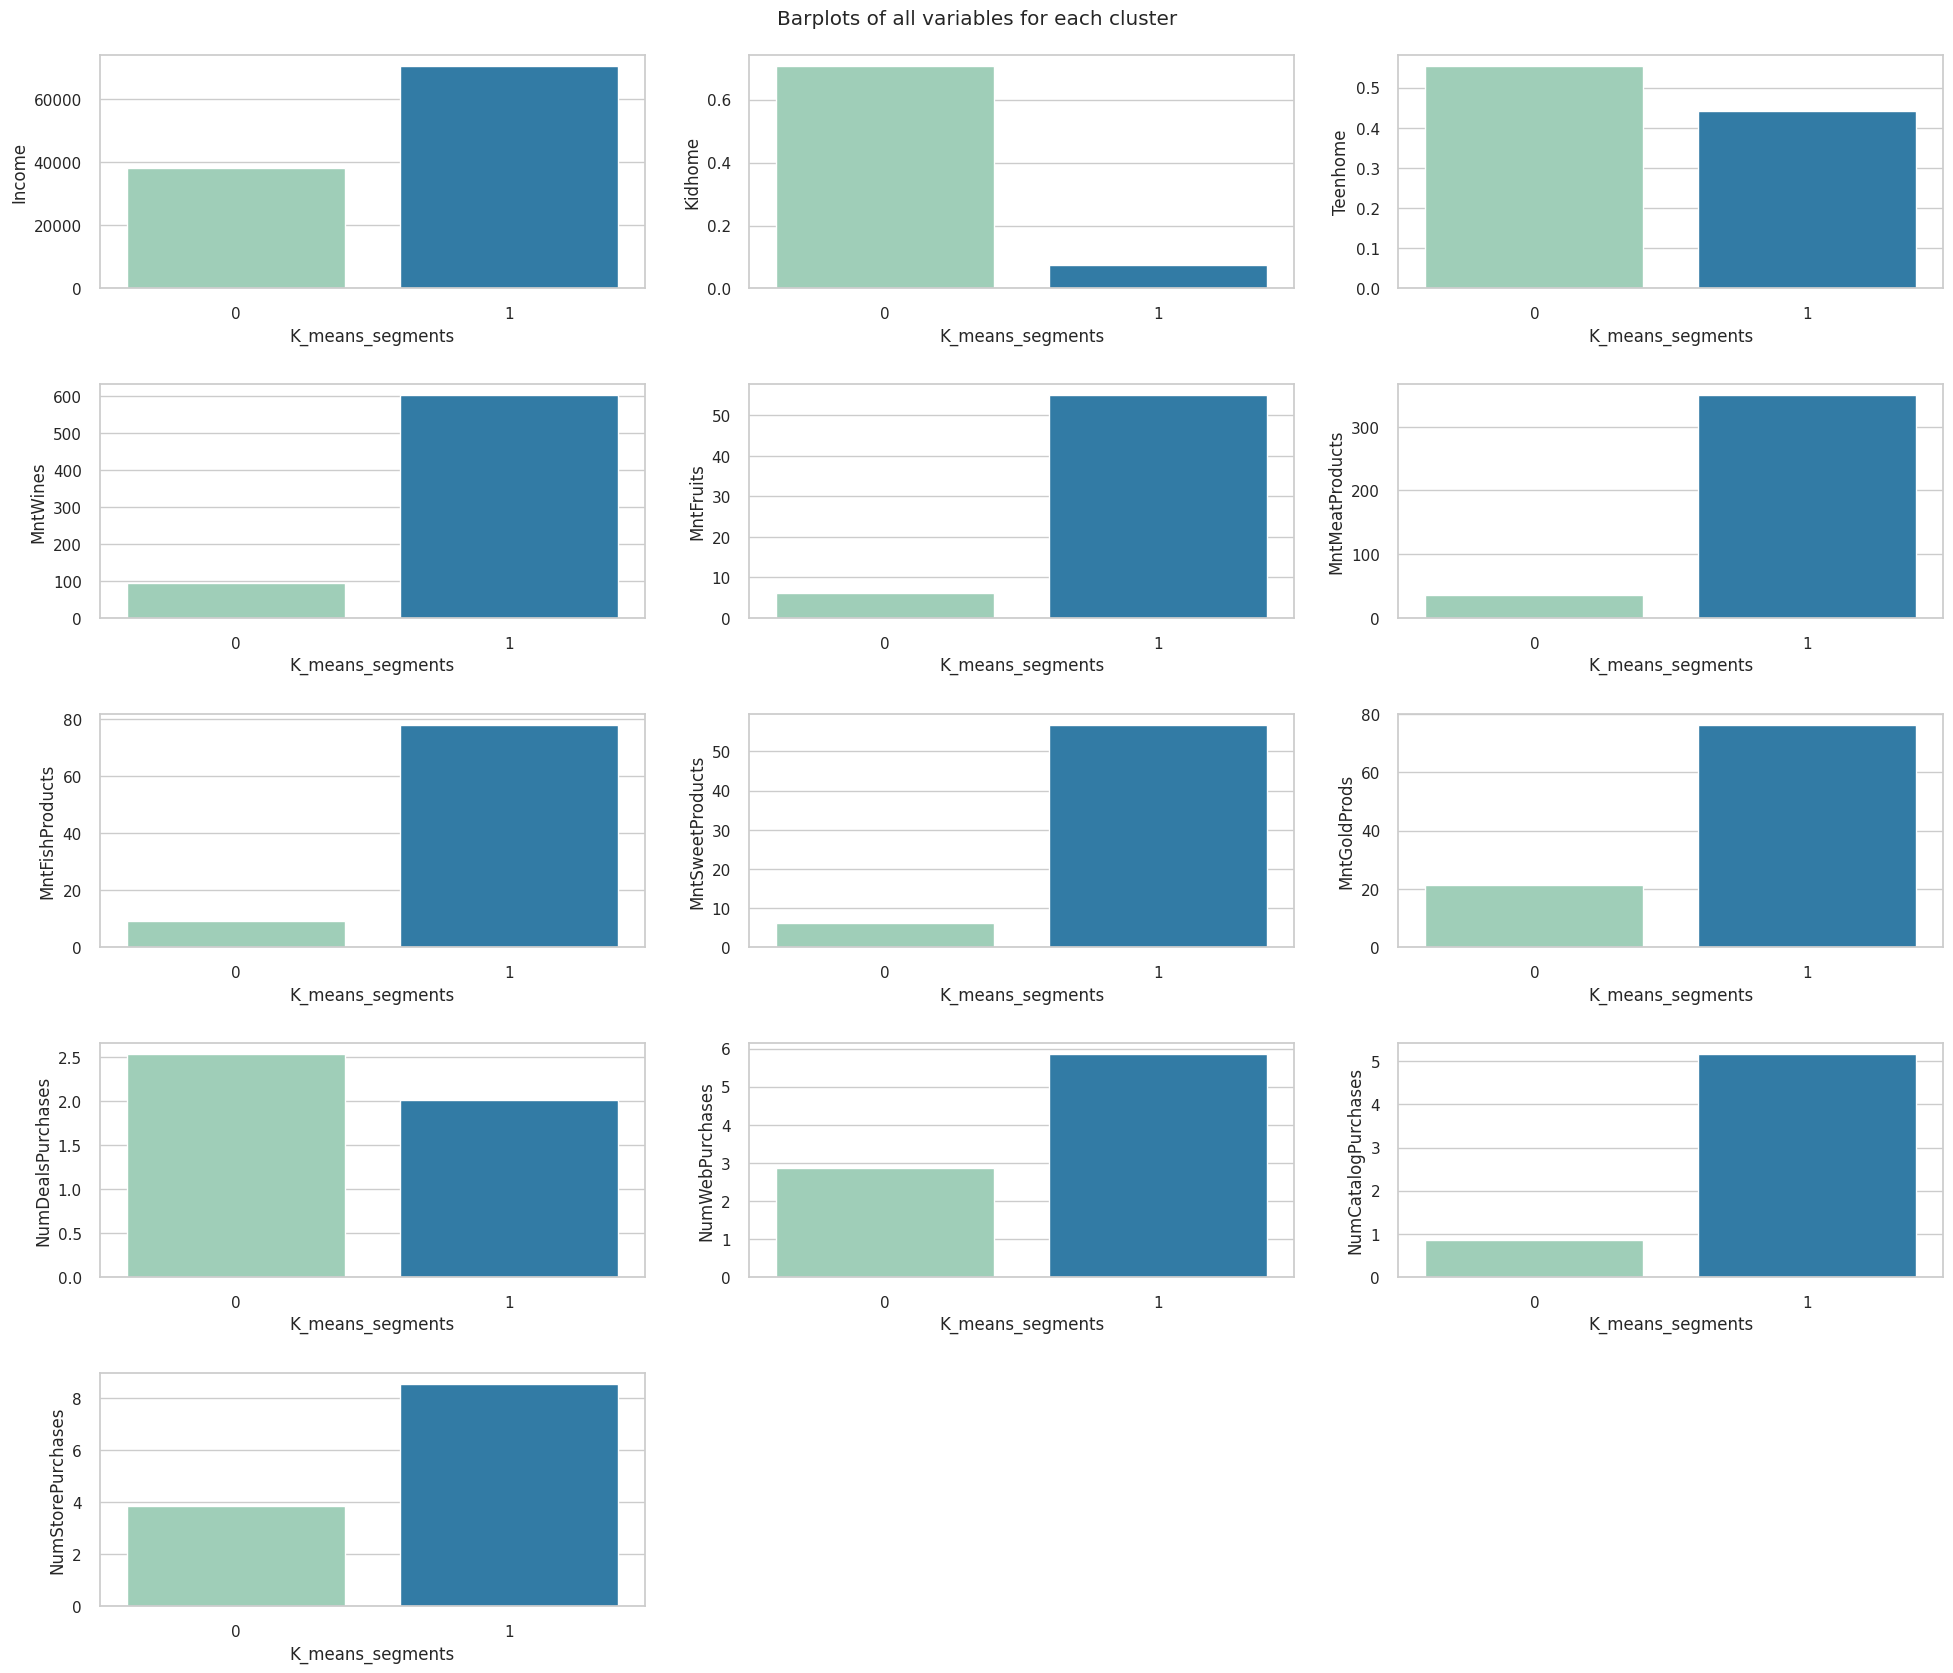

In [ ]:
# Prepare for plotting barplots of numerical variables for each cluster
plt.figure(figsize=(20, 20))  # Set the figure size for the plot
plt.suptitle("Barplots of all variables for each cluster")  # Set the main title for the plot

for i, variable in enumerate(df_new2.columns.to_list()[:-1]):
    plt.subplot(6, 3, i + 1)
    sns.barplot(data=df_new2, x='K_means_segments', y=variable, palette='YlGnBu', errorbar=None)

plt.tight_layout(pad=2.0)
plt.show()

# **Business Recommedations**

**Question 12: Based on the cluster insights, what business recommendations can be provided?**

**Cluster 1 (Blue): High income, no kids or possibly one teen**

**Profile:** This group has high purchasing power, spends more than others across all categories, and shows little interest in discounted products.

**Strategy:** This is the most profitable segment for the company. The focus should be on retaining these customers and attracting new ones with similar characteristics.

**Recommended Actions:**


*   Implement a premium loyalty program (for example: exclusive benefits based on spending level).
*   Enhance the personalized experience by sending a physical or digital catalog featuring gourmet product updates—especially award-winning wines and premium export-quality meat cuts.
*   Offer private tastings or exclusive events for this audience (such as wine pairing dinners or gourmet experiences).
*  Offer private tastings or exclusive events for this audience (such as wine pairing dinners or gourmet experiences).
*   Collaborate with content creators who reflect this segment's lifestyle to promote the brand and its premium products



---



**Cluster 2 (Green): Lower income, with children and/or teens**

**Profile:** This group is more price-sensitive, they spend less overall but have a higher proportion of discounted purchases.

**Strategy:** Although it is not the most profitable segment, it represents a significant sales volume.

**Recommended Actions:**


*   Strengthen promotional and discount campaigns, especially for essential products in households with kids.
*   Collaborate with content creators who reflect this segment's lifestyle to promote the company and its promotions.
*   Family discounts and promotions should place greater emphasis on online purchases and in-store products











